In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score,accuracy_score,precision_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import pickle

In [3]:
df=pd.read_csv("loan_approval_data.csv")

In [4]:
df.sample(5)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [5]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [6]:
categorical_cols=df.select_dtypes(include=['object']).columns
numerical_cols=df.select_dtypes(include=['number']).columns

In [7]:
num_imp = SimpleImputer(strategy='mean')
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

In [8]:
cat_imp = SimpleImputer(strategy='most_frequent')
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [9]:
df = df.drop(columns='Applicant_ID')

In [10]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
cols=["Employment_Status","Marital_Status","Property_Area","Employer_Category","Gender","Loan_Purpose"]
le=LabelEncoder()
ohe = OneHotEncoder(drop='first',sparse_output=False,handle_unknown="ignore",dtype=float)

In [11]:
df["Education_Level"]=le.fit_transform(df['Education_Level'])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)

In [12]:
df= pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [13]:
numerical_cols=df.select_dtypes(include=['number'])
corr_matrix= numerical_cols.corr()

In [14]:
corr_matrix['Loan_Approved'].sort_values()

DTI_Ratio                         -0.444783
Loan_Amount                       -0.126499
Loan_Term                         -0.086644
Loan_Purpose_Car                  -0.056416
Gender_Male                       -0.054342
Education_Level                   -0.052920
Employment_Status_Unemployed      -0.044464
Employment_Status_Salaried        -0.041428
Employer_Category_Government      -0.039187
Existing_Loans                    -0.034794
Dependents                        -0.023811
Age                               -0.022343
Employer_Category_Unemployed      -0.021468
Loan_Purpose_Education            -0.016684
Savings                           -0.013437
Property_Area_Semiurban           -0.012967
Employer_Category_Private         -0.003347
Employment_Status_Self-employed   -0.001337
Loan_Purpose_Home                  0.002118
Coapplicant_Income                 0.004230
Collateral_Value                   0.021868
Property_Area_Urban                0.025963
Marital_Status_Single           

<Axes: >

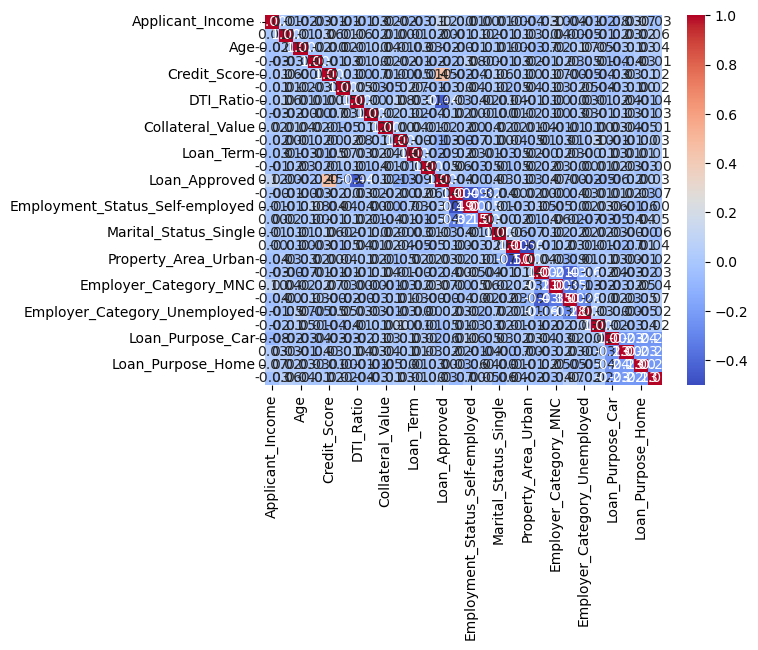

In [15]:
sns.heatmap(corr_matrix,cmap="coolwarm",fmt='.2f',annot=True)

In [16]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns='Loan_Approved'),df['Loan_Approved'],test_size=0.2,random_state=42)

In [17]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [18]:
modellog=LogisticRegression(max_iter=1000).fit(x_train_scaled,y_train)
y_pred= modellog.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))

0.865
0.7833333333333333
0.7704918032786885


In [19]:
knnClass=KNeighborsClassifier(n_neighbors=23)
knnClass.fit(x_train_scaled,y_train)
y_pred=knnClass.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.785
0.39344262295081966
0.8


In [20]:
for i in [5,7,9,11,13,15,17,19,21,23,25,27,29]:
    knnClass=KNeighborsClassifier(n_neighbors=i)
    knnClass.fit(x_train_scaled,y_train)
    y_pred=knnClass.predict(x_test_scaled)
    print(i)
    print(accuracy_score(y_test,y_pred))
    print(recall_score(y_test,y_pred))
    print(precision_score(y_test,y_pred))

5
0.76
0.5245901639344263
0.6274509803921569
7
0.745
0.45901639344262296
0.6086956521739131
9
0.76
0.4426229508196721
0.6585365853658537
11
0.765
0.4426229508196721
0.675
13
0.79
0.4918032786885246
0.7317073170731707
15
0.775
0.4262295081967213
0.7222222222222222
17
0.775
0.4098360655737705
0.7352941176470589
19
0.77
0.4098360655737705
0.7142857142857143
21
0.785
0.3770491803278688
0.8214285714285714
23
0.785
0.39344262295081966
0.8
25
0.785
0.3770491803278688
0.8214285714285714
27
0.775
0.3442622950819672
0.8076923076923077
29
0.77
0.3114754098360656
0.8260869565217391


In [21]:
gnb_model = GaussianNB()
gnb_model.fit(x_train_scaled,y_train)
y_pred=gnb_model.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))

0.865
0.8035714285714286
0.7377049180327869


In [22]:
categorical_cols=x_train.select_dtypes(include=['object']).columns.to_list()
numerical_cols=x_train.select_dtypes(include=['number']).columns.to_list()
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [23]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols),
])

In [24]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', GaussianNB())
])

In [25]:
model.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Applicant_Income',
                                                   'Coapplicant_Income', 'Age',
                                                   'Dependents', 'Credit_Score',
                                                   'Existing_Loans',
                                                   'DTI_Ratio', 'Savings',
                                                   'Collateral_Value',
                                                   'Loan_Amount', 'Loan_Term',
                                                   'Education_Level',
                                                   'Employment_Status_Salaried',
                                                   '...
                                                   'Employer_Category_MNC',
                                                   'Employer_Category_Private',
                                                   'Employer_Category_Unemployed',
                                                   'Gender_Male',
                                                   'Loan_Purpose_Car',
                                                   'Loan_Purpose_Education',
                                                   'Loan_Purpose_Home',
                                                   'Loan_Purpose_Personal']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('classifier', GaussianNB())])

In [26]:
y_pred=model.predict(x_test)

In [27]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))

0.865
0.8035714285714286
0.7377049180327869


In [28]:
with open('pipeline.pkl', 'wb') as f:
    pickle.dump(model, f)